# Projet 2 – Classification de la qualité du vin

**Machine Learning I – ING2-BDML – EFREI 2026/2027**
Responsables : Ahmed Ghazi BLAIECH / Ahmad TAY / Hassan SHRAIM

**Objectif :** construire un modèle de classification supervisée qui prédit si un vin est **bon (qualité ≥ 7)** ou non, à partir de ses caractéristiques physico-chimiques.

Le notebook suit les sections du sujet :
1. Prétraitement des données (§2.1)
2. Modélisation (§2.2)
3. Évaluation des modèles (§2.3)
4. Optimisation des hyperparamètres (§2.4)

La démarche reprend celle des TP du cours (TP1 arbre de décision, TP3 Naive Bayes) : chargement avec `read_csv`, passage en tableaux numpy, `Counter` pour les classes, `train_test_split` (25 % de test, `random_state=1`), `StandardScaler`, puis `confusion_matrix` / `classification_report` pour chaque modèle.

**Données :** jeu *Wine Quality* (UCI, Cortez et al., 2009) : 1 599 vins rouges et 4 898 vins blancs portugais (*vinho verde*), 11 variables physico-chimiques et une note de qualité de 0 à 10. Les fichiers `winequality-red.csv` et `winequality-white.csv` doivent être placés dans le dossier `data/` (sous Colab : les téléverser dans `data/`).

## 0. Importation des librairies

In [1]:
import numpy as np
np.set_printoptions (suppress=True)
import pandas as pd
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from collections import Counter
import os, time
os.makedirs('figures', exist_ok=True)   #dossier où l'on sauvegarde les figures du rapport
pd.set_option('display.precision', 3)
pd.set_option('display.max_colwidth', 120)

# 1. Prétraitement des données (§2.1)

## 1.1 Chargement des données
Comme dans le TP1, on importe les données avec `read_csv`. Les fichiers du jeu *Wine Quality* utilisent le séparateur `;`.
On utilise **les deux fichiers (rouge et blanc)** : cela double la taille de l'échantillon et introduit une variable catégorielle (le type de vin) qu'il faudra encoder.

In [2]:
rouge=pd.read_csv('data/winequality-red.csv',sep=';',header=0)
blanc=pd.read_csv('data/winequality-white.csv',sep=';',header=0)
#sep=';' : séparateur des fichiers wine quality ; header=0 : la première ligne contient les titres
rouge['type']='rouge'
blanc['type']='blanc'
vin=pd.concat([rouge,blanc],ignore_index=True)
vin.head(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.998,3.51,0.56,9.4,5,rouge
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.997,3.20,0.68,9.8,5,rouge
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.997,3.26,0.65,9.8,5,rouge


In [3]:
print(type(vin))
print('Vins rouges :', rouge.shape, '| Vins blancs :', blanc.shape, '| Total :', vin.shape)
vin.info()

<class 'pandas.DataFrame'>
Vins rouges : (1599, 13) | Vins blancs : (4898, 13) | Total : (6497, 13)
<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
m

## 1.2 Statistiques descriptives

In [4]:
vin.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215,1.296,3.800,6.400,7.000,7.700,15.900
volatile acidity,6497.0,0.340,0.165,0.080,0.230,0.290,0.400,1.580
citric acid,6497.0,0.319,0.145,0.000,0.250,0.310,0.390,1.660
residual sugar,6497.0,5.443,4.758,0.600,1.800,3.000,8.100,65.800
chlorides,6497.0,0.056,0.035,0.009,0.038,0.047,0.065,0.611
free sulfur dioxide,6497.0,30.525,17.749,1.000,17.000,29.000,41.000,289.000
total sulfur dioxide,6497.0,115.745,56.522,6.000,77.000,118.000,156.000,440.000
density,6497.0,0.995,0.003,0.987,0.992,0.995,0.997,1.039
pH,6497.0,3.219,0.161,2.720,3.110,3.210,3.320,4.010
sulphates,6497.0,0.531,0.149,0.220,0.430,0.510,0.600,2.000


type     blanc  rouge   All
quality                    
3           20     10    30
4          163     53   216
5         1457    681  2138
6         2198    638  2836
7          880    199  1079
8          175     18   193
9            5      0     5
All       4898   1599  6497


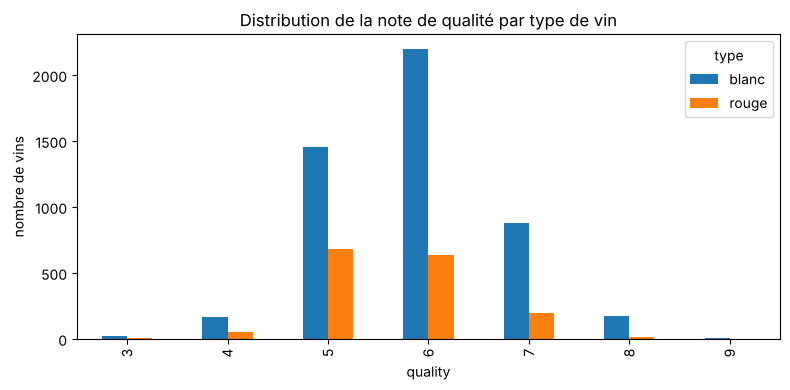

In [5]:
#Répartition de la note de qualité (0 à 10) par type de vin
print(pd.crosstab(vin['quality'], vin['type'], margins=True))
pd.crosstab(vin['quality'], vin['type']).plot(kind='bar', figsize=(8,4))
plt.title('Distribution de la note de qualité par type de vin')
plt.xlabel('quality'); plt.ylabel("nombre de vins")
plt.tight_layout(); plt.savefig('figures/01_qualite_par_type.png', dpi=110); plt.show()

**Lecture :** aucune note n'est inférieure à 3 ni supérieure à 9 ; l'essentiel des vins est noté 5 ou 6. Les vins de qualité 7 à 9 (les « bons vins ») sont nettement minoritaires.

## 1.3 Gestion des valeurs manquantes et des doublons

In [6]:
#Nombre de valeurs manquantes par variable
print(vin.isnull().sum())
print('Total valeurs manquantes :', vin.isnull().sum().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64
Total valeurs manquantes : 0


In [7]:
#Lignes strictement identiques (mêmes 11 mesures, même note, même type)
print('Nombre de doublons :', vin.duplicated().sum())
vin=vin.drop_duplicates().reset_index(drop=True)
print('Taille après suppression des doublons :', vin.shape)

Nombre de doublons : 1177
Taille après suppression des doublons : (5320, 13)


**Décision :**
- Le jeu ne contient **aucune valeur manquante** : aucune imputation n'est nécessaire.
- Il contient en revanche **1 177 lignes en double**. On les supprime : sinon une même observation peut se retrouver à la fois dans l'apprentissage et dans le test, ce qui surestime les performances (en particulier pour le k-NN et l'arbre de décision, qui « mémorisent » les exemples).

## 1.4 Détection des valeurs aberrantes
On visualise d'abord les distributions avec des **boxplots**, puis on compte les valeurs en dehors de l'intervalle $[Q_1 - 1{,}5\,IQR \; ; \; Q_3 + 1{,}5\,IQR]$ (règle des moustaches du boxplot).

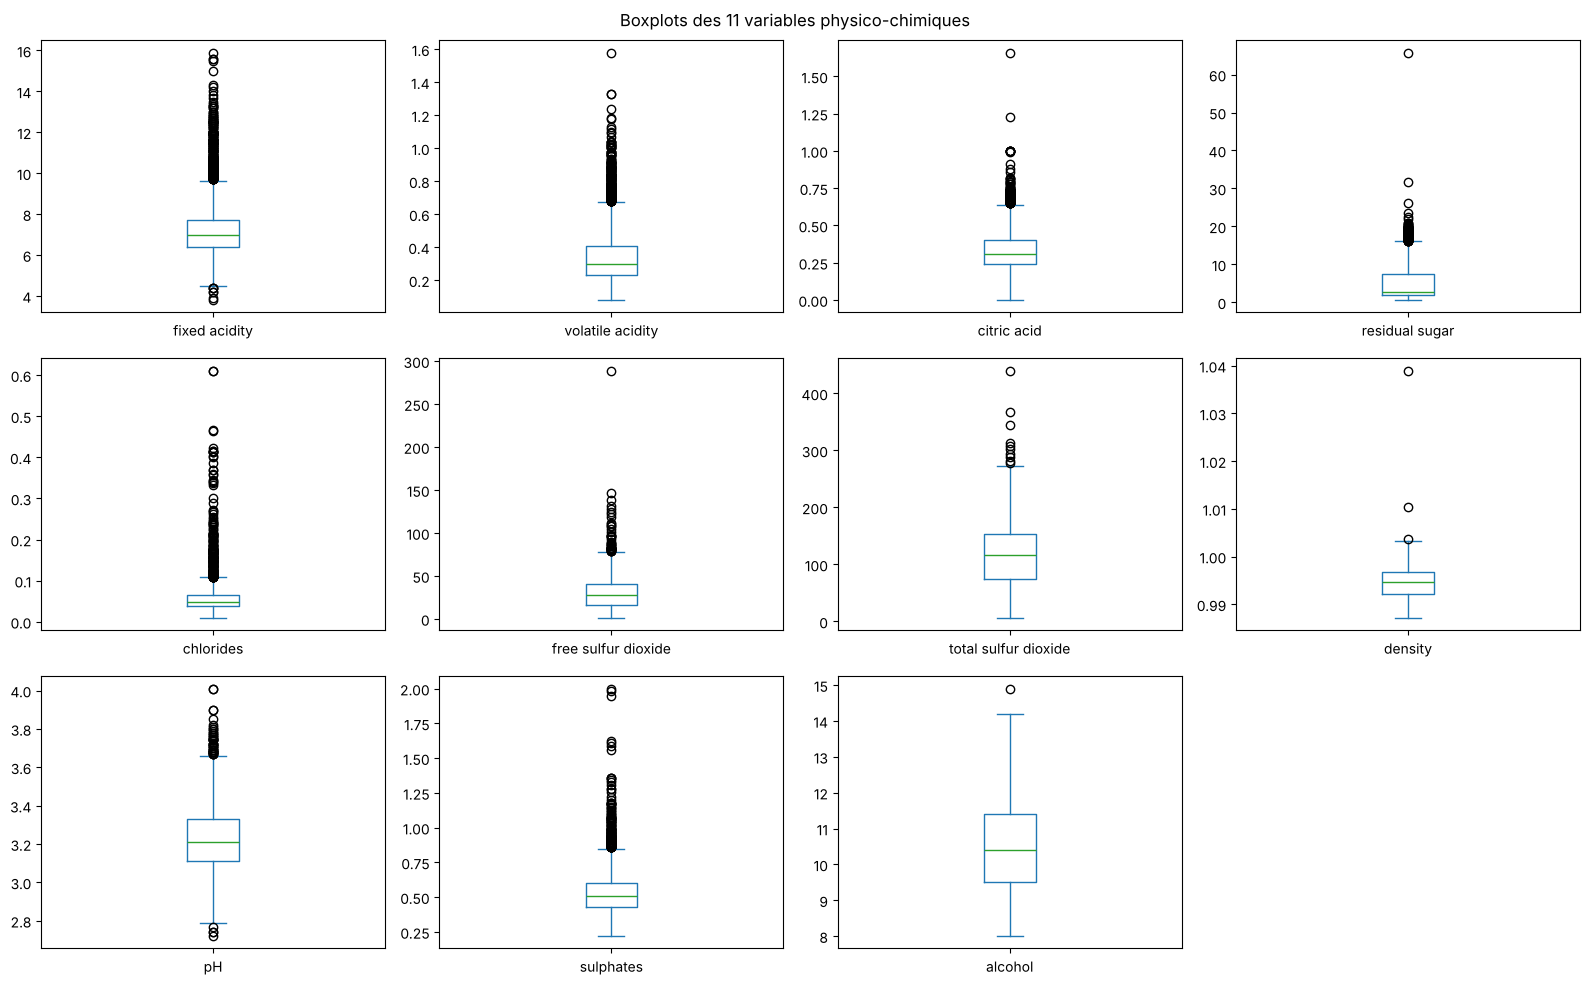

In [8]:
variables_num=list(vin.columns[:11])
vin[variables_num].plot(kind='box', subplots=True, layout=(3,4), figsize=(16,10), sharey=False)
plt.suptitle('Boxplots des 11 variables physico-chimiques')
plt.tight_layout(); plt.savefig('figures/02_boxplots.png', dpi=110); plt.show()

In [9]:
Q1=vin[variables_num].quantile(0.25)
Q3=vin[variables_num].quantile(0.75)
IQR=Q3-Q1
aberrant=(vin[variables_num]<Q1-1.5*IQR)|(vin[variables_num]>Q3+1.5*IQR)
tableau_aberrants=pd.DataFrame({'nb valeurs hors moustaches':aberrant.sum(),
                                '% des vins':(100*aberrant.mean()).round(1)})
print(tableau_aberrants)
print('\nVins ayant au moins une valeur hors moustaches : {0:.1f} %'.format(100*aberrant.any(axis=1).mean()))

                      nb valeurs hors moustaches  % des vins
fixed acidity                                304         5.7
volatile acidity                             279         5.2
citric acid                                  143         2.7
residual sugar                               141         2.7
chlorides                                    237         4.5
free sulfur dioxide                           44         0.8
total sulfur dioxide                          10         0.2
density                                        3         0.1
pH                                            49         0.9
sulphates                                    163         3.1
alcohol                                        1         0.0

Vins ayant au moins une valeur hors moustaches : 20.6 %


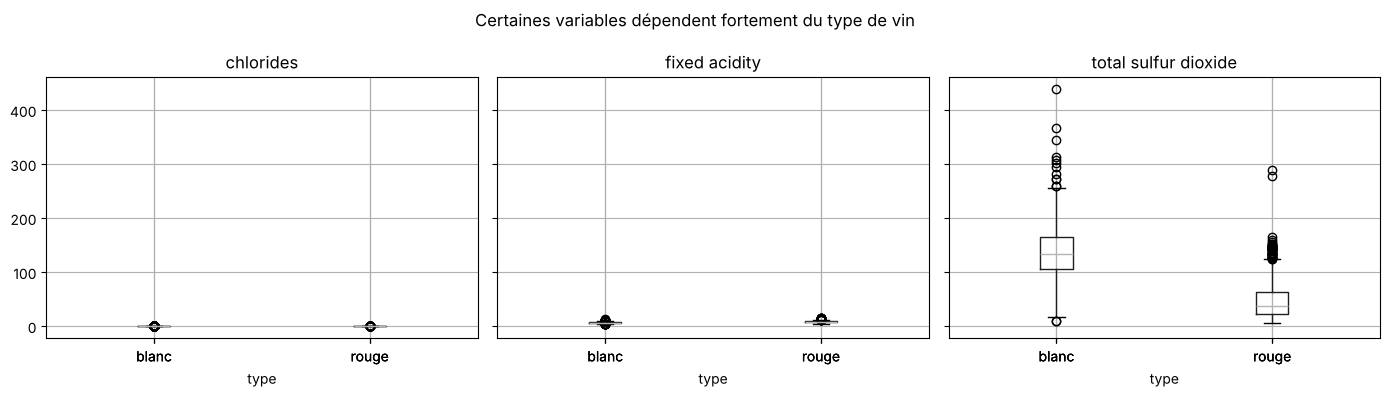

In [10]:
#Exemple : les chlorures et l'acidité fixe sont plus élevés dans les rouges -> une partie des "aberrants" vient du mélange rouge/blanc
vin.boxplot(column=['chlorides','fixed acidity','total sulfur dioxide'], by='type', layout=(1,3), figsize=(14,4))
plt.suptitle('Certaines variables dépendent fortement du type de vin')
plt.tight_layout(); plt.show()

Environ **un vin sur cinq** possède au moins une valeur hors moustaches. Les supprimer ferait perdre trop de données, et la plupart de ces valeurs ne sont pas des erreurs :
- les distributions de `residual sugar`, `chlorides` ou `sulphates` sont **asymétriques** (longue queue à droite), ce qui produit mécaniquement beaucoup de points hors moustaches ;
- une partie des écarts vient du **mélange rouge/blanc** (les rouges ont plus de chlorures, d'acidité fixe et moins de SO₂ total).

**Décision :** on conserve ces valeurs et on ne supprime que les **valeurs extrêmes**, situées à plus de **5 écarts-types** de la moyenne (|z-score| > 5). Elles sont très rares et isolées (par exemple 65,8 g/L de sucre résiduel ou 289 mg/L de SO₂ libre) et perturberaient la normalisation et les méthodes à distance (k-NN, SVM).

In [11]:
z=(vin[variables_num]-vin[variables_num].mean())/vin[variables_num].std()
extremes=(z.abs()>5).any(axis=1)
print('Vins avec au moins une valeur à plus de 5 écarts-types :', extremes.sum())
print((z.abs()>5).sum()[(z.abs()>5).sum()>0])
vin=vin[~extremes].reset_index(drop=True)
print('Taille après suppression des valeurs extrêmes :', vin.shape)

Vins avec au moins une valeur à plus de 5 écarts-types : 62
fixed acidity            8
volatile acidity         4
citric acid              2
residual sugar           2
chlorides               32
free sulfur dioxide      7
total sulfur dioxide     1
density                  2
sulphates               13
dtype: int64
Taille après suppression des valeurs extrêmes : (5258, 13)


## 1.5 Encodage des variables catégorielles
La seule variable non numérique est `type` (rouge / blanc). Comme vu en séance 1 (*Data conversion*), on la code en représentation numérique : variable binaire `type_rouge` (1 = rouge, 0 = blanc).

In [12]:
vin['type_rouge']=(vin['type']=='rouge').astype(int)
vin=vin.drop(columns='type')
print(vin['type_rouge'].value_counts())

type_rouge
0    3943
1    1315
Name: count, dtype: int64


## 1.6 Transformation en problème de classification binaire
Consigne du sujet : **qualité ≥ 7 → bon vin (classe 1)**, sinon classe 0. La note `quality` est ensuite retirée des variables explicatives (sinon le modèle connaîtrait la réponse).

In [13]:
vin['bon_vin']=(vin['quality']>=7).astype(int)
qualite=vin['quality']            #conservée à part pour les graphiques
vin=vin.drop(columns='quality')
vin.head(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type_rouge,bon_vin
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.998,3.51,0.56,9.4,1,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.997,3.20,0.68,9.8,1,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.997,3.26,0.65,9.8,1,0


In [14]:
#l'initialisation de X : les colonnes qui sont traitées
variables=list(vin.columns[:-1])
X=vin[variables].values
#l'initialisation de Y : la colonne qui contient le résultat
Y=vin['bon_vin'].values
print('X :', X.shape, '| Y :', Y.shape)
print('Variables explicatives :', variables)

X : (5258, 12) | Y : (5258,)
Variables explicatives : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'type_rouge']


## 1.7 Distribution des classes
On reprend le code du TP1 (`Counter` + `plt.bar`).

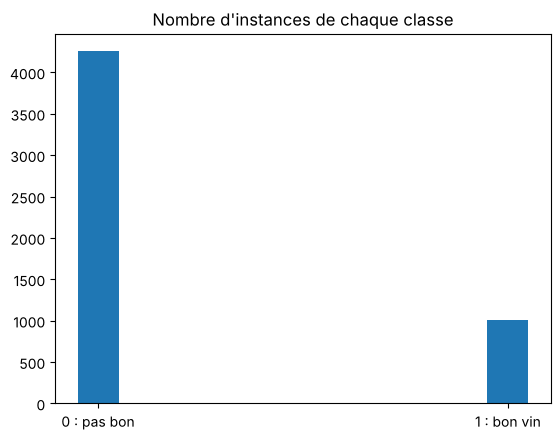

In [15]:
histogram=Counter(Y)
plt.bar(histogram.keys(),histogram.values() , 0.1)
plt.xticks([0,1],['0 : pas bon','1 : bon vin'])
plt.title("Nombre d'instances de chaque classe")
plt.savefig('figures/03_classes.png', dpi=110); plt.show()
#Afficher le nbre d'instance de la colonne Y

In [16]:
ep=np.sum(Y==1)/len(Y)  #len: Total
nep=np.sum(Y==0)/len(Y)
print('Bon vin : {0:.3f} et Non : {1:.3f}'.format(ep,nep))
print('Proportion de bons vins : rouges {0:.3f} / blancs {1:.3f}'.format(
      vin.loc[vin.type_rouge==1,'bon_vin'].mean(), vin.loc[vin.type_rouge==0,'bon_vin'].mean()))

Bon vin : 0.191 et Non : 0.809
Proportion de bons vins : rouges 0.137 / blancs 0.209


**Le jeu de données est déséquilibré** : environ 19 % de bons vins pour 81 % de vins « non bons ».

Conséquences pour la suite :
- un modèle qui répondrait toujours « pas bon » obtiendrait déjà ≈ 81 % d'accuracy : **l'accuracy seule est trompeuse** ;
- on suivra en priorité le **rappel**, la **précision**, le **F1-score** de la classe 1 et l'**AUC** ;
- la séparation apprentissage/test sera **stratifiée** pour conserver la même proportion de bons vins dans les deux parties ;
- lors de l'optimisation, on testera le paramètre `class_weight='balanced'`, qui donne plus de poids à la classe minoritaire.

## 1.8 Analyse des corrélations

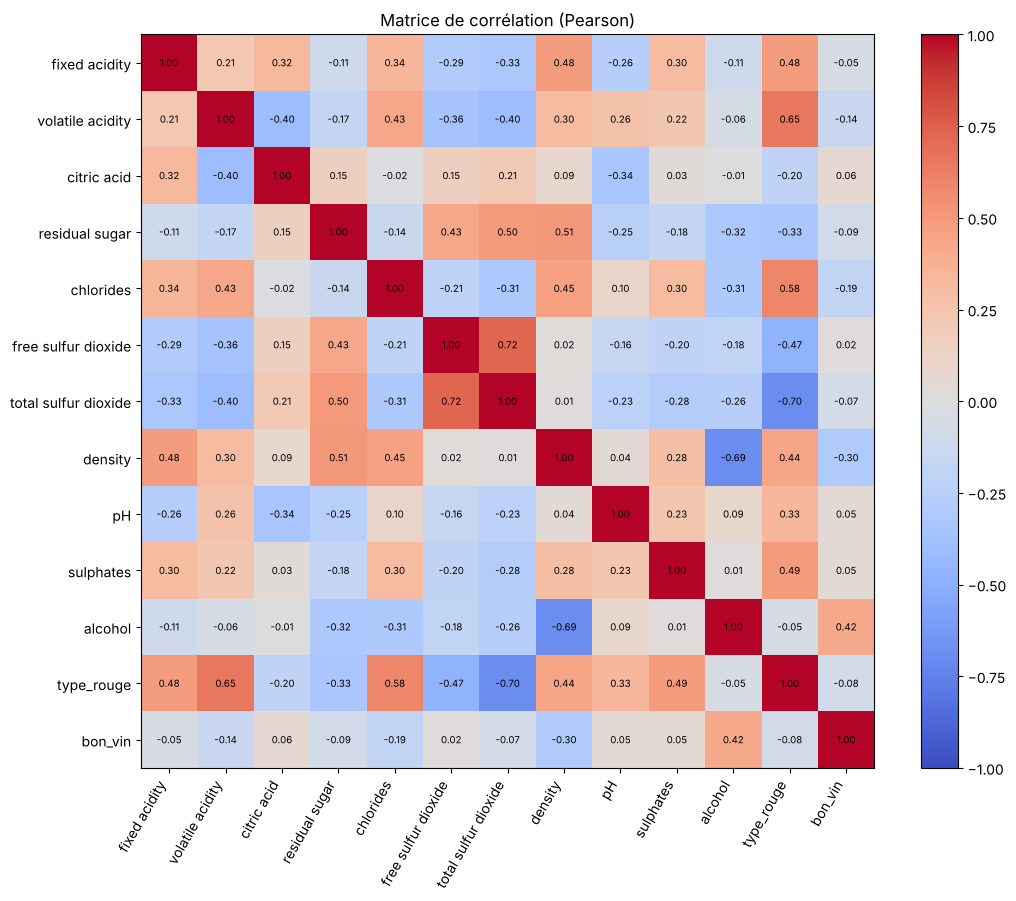

In [17]:
corr=vin.corr()
fig,ax=plt.subplots(figsize=(11,9))
im=ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=60, ha='right')
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, '{:.2f}'.format(corr.iloc[i,j]), ha='center', va='center', fontsize=7)
plt.colorbar(im); plt.title('Matrice de corrélation (Pearson)')
plt.tight_layout(); plt.savefig('figures/04_matrice_correlation.png', dpi=110); plt.show()

density                -0.303
chlorides              -0.192
volatile acidity       -0.142
residual sugar         -0.087
type_rouge             -0.080
total sulfur dioxide   -0.067
fixed acidity          -0.052
free sulfur dioxide     0.015
pH                      0.047
sulphates               0.051
citric acid             0.064
alcohol                 0.420
Name: bon_vin, dtype: float64


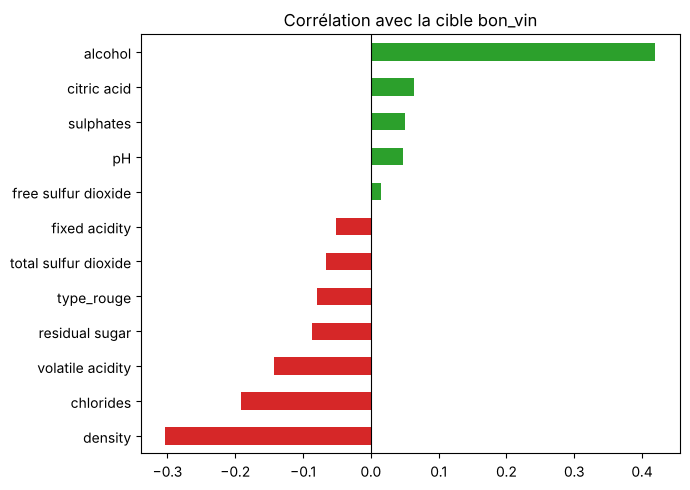

In [18]:
#Corrélation de chaque variable avec la cible bon_vin
corr_cible=corr['bon_vin'].drop('bon_vin').sort_values()
print(corr_cible)
corr_cible.plot(kind='barh', figsize=(7,5), color=['tab:red' if v<0 else 'tab:green' for v in corr_cible])
plt.title('Corrélation avec la cible bon_vin'); plt.axvline(0,color='k',lw=0.8)
plt.tight_layout(); plt.savefig('figures/05_correlation_cible.png', dpi=110); plt.show()

In [19]:
#Paires de variables fortement corrélées entre elles (|r| > 0.6)
paires=[(corr.columns[i],corr.columns[j],round(corr.iloc[i,j],2))
        for i in range(len(corr)) for j in range(i+1,len(corr)) if abs(corr.iloc[i,j])>0.6]
for p in paires: print(p)

('volatile acidity', 'type_rouge', np.float64(0.65))
('free sulfur dioxide', 'total sulfur dioxide', np.float64(0.72))
('total sulfur dioxide', 'type_rouge', np.float64(-0.7))
('density', 'alcohol', np.float64(-0.69))


**Lecture :**
- `alcohol` est de loin la variable la plus liée à la qualité (corrélation positive), suivie de `density` (corrélation négative). Les deux sont d'ailleurs fortement corrélées entre elles (un vin plus alcoolisé est moins dense).
- `chlorides` et `volatile acidity` sont corrélées négativement avec la qualité.
- Certaines variables sont **redondantes** : `free sulfur dioxide` / `total sulfur dioxide`, `density` / `residual sugar` / `alcohol`, et `type_rouge` avec `total sulfur dioxide` et `volatile acidity`.
- Ces corrélations entre variables contredisent l'hypothèse d'**indépendance** de Naive Bayes (séance 3) : on s'attend à ce que ce modèle soit pénalisé.

## 1.9 Visualisations : histogrammes et boxplots par classe

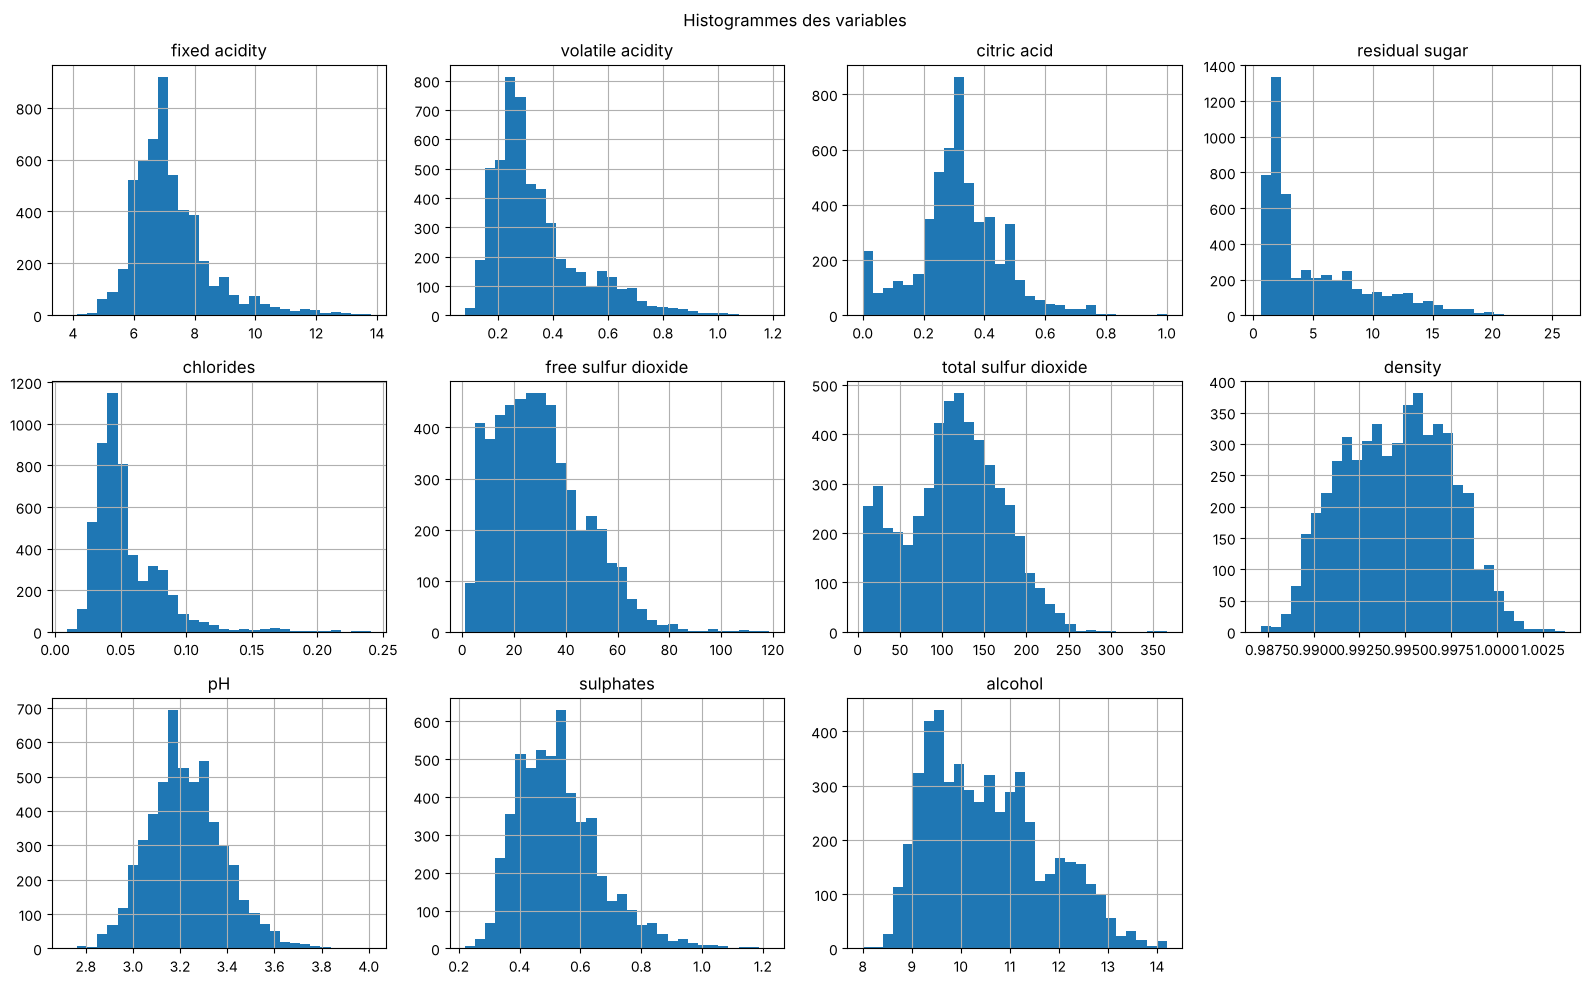

In [20]:
vin[variables_num].hist(bins=30, figsize=(16,10), layout=(3,4))
plt.suptitle('Histogrammes des variables')
plt.tight_layout(); plt.savefig('figures/06_histogrammes.png', dpi=110); plt.show()

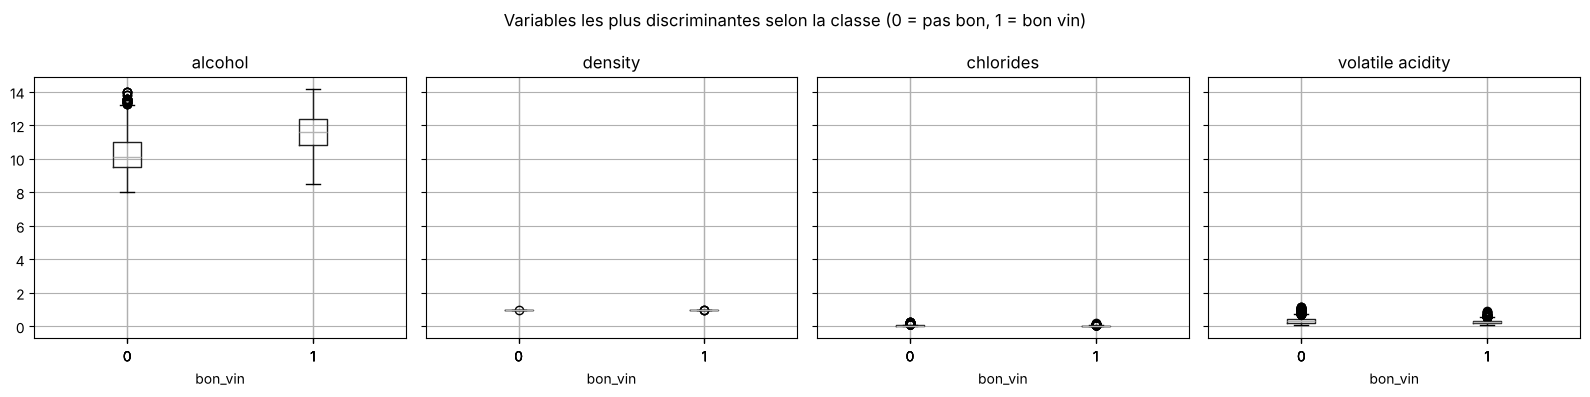

In [21]:
#Distribution des variables les plus liées à la cible, selon la classe
vin.boxplot(column=['alcohol','density','chlorides','volatile acidity'], by='bon_vin', layout=(1,4), figsize=(16,4))
plt.suptitle('Variables les plus discriminantes selon la classe (0 = pas bon, 1 = bon vin)')
plt.tight_layout(); plt.savefig('figures/07_boxplots_par_classe.png', dpi=110); plt.show()

Les histogrammes confirment que plusieurs variables sont **asymétriques** (`residual sugar`, `chlorides`, `free sulfur dioxide`, `sulphates`) et ne suivent pas une loi normale, ce qui est une autre limite pour Naive Bayes gaussien. Les bons vins sont nettement **plus alcoolisés**, **moins denses** et contiennent **moins de chlorures**.

## 1.10 Séparation des données apprentissage / test
Comme dans le TP1 : 25 % des individus pour le test, `random_state=1`. On ajoute `stratify=Y` pour garder la même proportion de bons vins dans les deux parties (jeu déséquilibré).

In [22]:
from sklearn.model_selection import train_test_split

#Importation des algorithmes
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

#Importation des métriques
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,roc_curve,classification_report
#Importation des Standards de normalisation
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [23]:
Xtrain,Xtest,Ytrain,Ytest=train_test_split(X,Y,test_size=0.25,random_state=1,stratify=Y)
#La base de test contiendra 25% des individus de la base totale.
print('Apprentissage :', Xtrain.shape, '| Test :', Xtest.shape)
print('Proportion de bons vins - train : {0:.3f} / test : {1:.3f}'.format(Ytrain.mean(), Ytest.mean()))

Apprentissage : (3943, 12) | Test : (1315, 12)
Proportion de bons vins - train : 0.191 / test : 0.191


## 1.11 Normalisation des données avec StandardScaler
Code du TP1 : le scaler est **ajusté uniquement sur l'apprentissage**, puis appliqué au test (pas de fuite d'information du test vers l'apprentissage).

In [24]:
ss=StandardScaler()
ss.fit(Xtrain)
Xtrain_norm=ss.transform(Xtrain)
Xtest_norm=ss.transform(Xtest)
print('Moyennes après normalisation (train) :', Xtrain_norm.mean(axis=0).round(2))
print('Écarts-types après normalisation (train) :', Xtrain_norm.std(axis=0).round(2))

Moyennes après normalisation (train) : [ 0. -0.  0. -0. -0. -0.  0.  0.  0. -0. -0.  0.]
Écarts-types après normalisation (train) : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 1.12 Sélection de variables (Feature selection)
On applique les trois familles de méthodes vues en séance 1, **uniquement sur la base d'apprentissage** :

| Famille | Méthode(s) | Principe |
|---|---|---|
| **Filter** | coefficient de Pearson, Chi², information mutuelle | score statistique entre chaque variable et la cible |
| **Wrapper** | Recursive Feature Elimination (RFE) | un modèle évalue des sous-ensembles et élimine les variables une à une |
| **Embedded** | Lasso, Ridge | la régularisation intégrée au modèle annule (Lasso) ou réduit (Ridge) les coefficients inutiles |

Pour chaque méthode, on retient les **6 meilleures variables** (ou les coefficients non nuls pour le Lasso), puis on fait voter les méthodes.

In [25]:
from sklearn.feature_selection import chi2, mutual_info_classif, RFE
from sklearn.linear_model import Lasso, Ridge

Xtrain_df=pd.DataFrame(Xtrain,columns=variables)
nb_retenues=6

# --- Filter 1 : coefficient de corrélation de Pearson avec la cible (en valeur absolue)
pearson=Xtrain_df.corrwith(pd.Series(Ytrain)).abs()

# --- Filter 2 : Chi² (nécessite des valeurs positives -> normalisation min-max)
mm=MinMaxScaler().fit(Xtrain)
chi2_scores,chi2_pvalues=chi2(mm.transform(Xtrain),Ytrain)
chi2_scores=pd.Series(chi2_scores,index=variables)

# --- Filter 3 : information mutuelle
mi=pd.Series(mutual_info_classif(Xtrain,Ytrain,random_state=0),index=variables)

# --- Wrapper : RFE avec une régression logistique sur données normalisées
rfe=RFE(LogisticRegression(max_iter=1000),n_features_to_select=nb_retenues).fit(Xtrain_norm,Ytrain)
rfe_rang=pd.Series(rfe.ranking_,index=variables)

# --- Embedded : Lasso (pénalité L1) et Ridge (pénalité L2) sur données normalisées
lasso=Lasso(alpha=0.01).fit(Xtrain_norm,Ytrain)
lasso_coef=pd.Series(lasso.coef_,index=variables)
ridge=Ridge(alpha=1.0).fit(Xtrain_norm,Ytrain)
ridge_coef=pd.Series(ridge.coef_,index=variables)

scores=pd.DataFrame({'|Pearson|':pearson,'Chi2':chi2_scores,'Info. mutuelle':mi,
                     'Rang RFE':rfe_rang,'Coef. Lasso':lasso_coef,'Coef. Ridge':ridge_coef})
scores.sort_values('|Pearson|',ascending=False)

,|Pearson|,Chi2,Info. mutuelle,Rang RFE,Coef. Lasso,Coef. Ridge
alcohol,0.420,61.897,9.395e-02,1,1.542e-01,0.069
density,0.307,26.420,5.043e-02,1,-0.000e+00,-0.195
chlorides,0.193,10.765,3.560e-02,5,-1.033e-02,-0.011
volatile acidity,0.140,7.346,1.454e-02,1,-2.964e-02,-0.026
residual sugar,0.097,6.514,2.399e-02,1,0.000e+00,0.118
type_rouge,0.081,19.672,7.791e-03,6,-0.000e+00,0.034
citric acid,0.068,1.199,2.234e-02,7,2.486e-03,0.013
total sulfur dioxide,0.062,1.211,2.466e-02,4,-0.000e+00,-0.032
sulphates,0.059,0.851,1.407e-02,2,2.553e-02,0.051
pH,0.047,0.336,8.633e-04,1,4.734e-04,0.062


In [26]:
#Vote : chaque méthode "sélectionne" ses meilleures variables
selection=pd.DataFrame(index=variables)
selection['Pearson']=pearson.rank(ascending=False)<=nb_retenues
selection['Chi2']=chi2_scores.rank(ascending=False)<=nb_retenues
selection['Info. mutuelle']=mi.rank(ascending=False)<=nb_retenues
selection['RFE']=rfe.support_
selection['Lasso']=lasso_coef.abs()>0
selection['Ridge']=ridge_coef.abs().rank(ascending=False)<=nb_retenues
selection['Nb votes']=selection.sum(axis=1)
selection=selection.sort_values('Nb votes',ascending=False)
print(selection.astype(int))

                      Pearson  Chi2  Info. mutuelle  RFE  Lasso  Ridge  \
alcohol                     1     1               1    1      1      1   
residual sugar              1     1               1    1      0      1   
density                     1     1               1    1      0      1   
volatile acidity            1     1               0    1      1      0   
chlorides                   1     1               1    0      1      0   
pH                          0     0               0    1      1      1   
citric acid                 0     0               1    0      1      0   
fixed acidity               0     0               0    1      0      1   
sulphates                   0     0               0    0      1      1   
type_rouge                  1     1               0    0      0      0   
total sulfur dioxide        0     0               1    0      0      0   
free sulfur dioxide         0     0               0    0      1      0   

                      Nb votes  
alco

In [27]:
variables_selectionnees=list(selection.index[selection['Nb votes']>=3])
print('Variables retenues (au moins 3 votes sur 6) :', len(variables_selectionnees))
print(variables_selectionnees)
print('Variables écartées :', [v for v in variables if v not in variables_selectionnees])

idx_sel=[variables.index(v) for v in variables_selectionnees]
Xtrain_sel_norm=Xtrain_norm[:,idx_sel]
Xtest_sel_norm=Xtest_norm[:,idx_sel]

Variables retenues (au moins 3 votes sur 6) : 6
['alcohol', 'residual sugar', 'density', 'volatile acidity', 'chlorides', 'pH']
Variables écartées : ['fixed acidity', 'citric acid', 'free sulfur dioxide', 'total sulfur dioxide', 'sulphates', 'type_rouge']


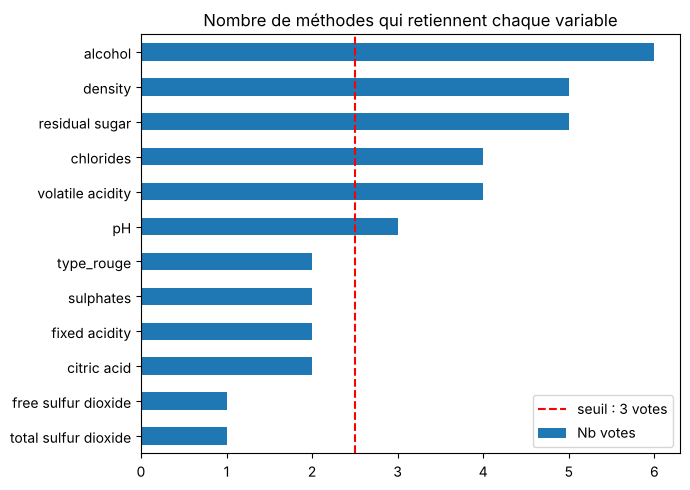

In [28]:
selection['Nb votes'].sort_values().plot(kind='barh', figsize=(7,5), color='tab:blue')
plt.axvline(2.5, color='red', ls='--', label='seuil : 3 votes')
plt.title('Nombre de méthodes qui retiennent chaque variable'); plt.legend()
plt.tight_layout(); plt.savefig('figures/08_selection_variables.png', dpi=110); plt.show()

Les trois familles de méthodes s'accordent sur un noyau de variables : `alcohol` (retenue par les 6 méthodes), `density` et `residual sugar` (5 votes), `volatile acidity` et `chlorides` (4 votes). On conserve le sous-ensemble obtenu par vote ; à l'étape suivante, on comparera les modèles **avec toutes les variables** et **avec les variables sélectionnées**, pour vérifier si la sélection simplifie le modèle sans perdre de performance (objectif de la sélection de variables, séance 1).

# 2. Modélisation (§2.2)

## 2.1 Choix et justification des modèles

| Modèle | Linéaire ? | Propriétés théoriques | Adaptabilité à nos données |
|---|---|---|---|
| **Régression logistique** | Oui | Frontière de décision linéaire $wx+b$ passée dans une sigmoïde (séance 2) ; sortie probabiliste ; peu de variance | Variables continues : OK. Sensible à l'échelle (normalisation utile) et aux variables corrélées. Peut manquer des relations non linéaires (biais). |
| **k-NN** | Non | Vote des k voisins les plus proches ; aucun apprentissage explicite ; frontière très flexible | Repose sur une **distance** : la normalisation est indispensable. Sensible au bruit et aux valeurs extrêmes, et à la classe majoritaire (déséquilibre). |
| **Arbre de décision** | Non | Partitions successives par tests sur les variables ; critère d'entropie / gain d'information (ID3, C4.5 – séance 2) ; seuils pour les attributs continus | Insensible à l'échelle (pas besoin de normaliser). Interprétable. Sans limite de profondeur : **forte variance** (surapprentissage). |
| **Naive Bayes gaussien** | Non (frontière quadratique en général) | Règle de Bayes + hypothèse d'**indépendance** des variables + loi **normale** de chaque variable dans chaque classe (séance 3) | Rapide et peu de variance, mais nos variables sont **corrélées** et **asymétriques** : les hypothèses ne sont pas respectées → biais attendu. |
| **SVM linéaire** | Oui | Hyperplan qui maximise la marge entre les classes | Robuste en grande dimension ; sensible à l'échelle. |
| **SVM noyau RBF** | Non | Même principe, dans un espace transformé par un noyau gaussien | Capture les relations non linéaires ; les paramètres `C` et `gamma` règlent le compromis biais/variance. |

On teste ainsi des modèles **linéaires** (logistique, SVM linéaire) et **non linéaires** (k-NN, arbre, SVM RBF, Naive Bayes) pour savoir si la frontière entre bons et moins bons vins est simple ou non.

## 2.2 Fonction de comparaison des modèles
Comme demandé dans le TP1, on développe une fonction qui entraîne un modèle et calcule ses performances. On y ajoute toutes les métriques du sujet.
La **moyenne accuracy + rappel** du TP1 est conservée, mais vu le déséquilibre des classes, le **F1-score** et l'**AUC** seront nos critères principaux.

In [29]:
from sklearn.base import clone

def evaluer_modele(nom, modele, Xtr, Ytr, Xte, Yte, afficher=True):
    #Entraîne le modèle, prédit sur le test et retourne les métriques
    modele.fit(Xtr,Ytr)
    Ypred=modele.predict(Xte)
    Ypred_train=modele.predict(Xtr)
    if hasattr(modele,'predict_proba'):
        score=modele.predict_proba(Xte)[:,1]
    else:
        score=modele.decision_function(Xte)
    acc=accuracy_score(Yte,Ypred)
    rec=recall_score(Yte,Ypred)
    if afficher:
        print ('************* Performance Evaluation of '+nom+' *************')
        print(confusion_matrix(Yte,Ypred))
        print(classification_report(Yte,Ypred,zero_division=0))
    return {'Modèle':nom,
            'Accuracy':acc,
            'Précision':precision_score(Yte,Ypred,zero_division=0),
            'Rappel':rec,
            'F1':f1_score(Yte,Ypred),
            'AUC':roc_auc_score(Yte,score),
            'Moy. acc+rappel (TP1)':(acc+rec)/2,
            'Accuracy train':accuracy_score(Ytr,Ypred_train),
            'F1 train':f1_score(Ytr,Ypred_train)}

def tableau(resultats):
    return pd.DataFrame(resultats).set_index('Modèle').sort_values('F1',ascending=False)

In [30]:
modeles={
    'Régression logistique':LogisticRegression(max_iter=1000),
    'k-NN (k=5)':KNeighborsClassifier(n_neighbors=5),
    'Arbre de décision':DecisionTreeClassifier(random_state=0, criterion='entropy'),
    'Naive Bayes':GaussianNB(),
    'SVM linéaire':SVC(kernel='linear', probability=True, random_state=0),
    'SVM RBF':SVC(kernel='rbf', probability=True, random_state=0)}

## 2.3 Apprentissage sur les données brutes (non normalisées)
Partie 3 du TP1 : on entraîne d'abord chaque modèle sur les données d'origine. Le SVM linéaire est très lent sans normalisation (variables d'échelles très différentes : de 0,01 pour les chlorures à plus de 300 pour le SO₂ total) ; on limite donc son nombre d'itérations.

In [31]:
resultats_bruts=[]
for nom,modele in modeles.items():
    m=clone(modele)
    if nom=='SVM linéaire': m.set_params(max_iter=20000)   #ne converge pas sans normalisation
    debut=time.time()
    r=evaluer_modele(nom,m,Xtrain,Ytrain,Xtest,Ytest,afficher=(nom=='Arbre de décision'))
    r['Temps (s)']=time.time()-debut
    resultats_bruts.append(r)
tableau(resultats_bruts)

************* Performance Evaluation of Arbre de décision *************
[[920 144]
 [140 111]]
              precision    recall  f1-score   support

           0       0.87      0.86      0.87      1064
           1       0.44      0.44      0.44       251

    accuracy                           0.78      1315
   macro avg       0.65      0.65      0.65      1315
weighted avg       0.79      0.78      0.78      1315



,Accuracy,Précision,Rappel,F1,AUC,Moy. acc+rappel (TP1),Accuracy train,F1 train,Temps (s)
Modèle,,,,,,,,,
Naive Bayes,0.741,0.387,0.610,0.474,0.767,0.676,0.760,0.510,0.017
Arbre de décision,0.784,0.435,0.442,0.439,0.653,0.613,1.000,1.000,0.051
Régression logistique,0.822,0.560,0.315,0.403,0.819,0.568,0.826,0.393,0.287
SVM linéaire,0.554,0.226,0.554,0.321,0.589,0.554,0.557,0.317,2.861
k-NN (k=5),0.792,0.411,0.211,0.279,0.689,0.501,0.852,0.501,0.051
SVM RBF,0.809,0.000,0.000,0.000,0.788,0.405,0.809,0.000,1.857


## 2.4 Apprentissage après normalisation
Partie 4 du TP1 : on refait l'apprentissage avec `Xtrain_norm` et `Xtest_norm`.

In [32]:
resultats_norm=[]
for nom,modele in modeles.items():
    debut=time.time()
    r=evaluer_modele(nom,clone(modele),Xtrain_norm,Ytrain,Xtest_norm,Ytest)
    r['Temps (s)']=time.time()-debut
    resultats_norm.append(r)
tab_norm=tableau(resultats_norm)
tab_norm

************* Performance Evaluation of Régression logistique *************
[[995  69]
 [164  87]]
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      1064
           1       0.56      0.35      0.43       251

    accuracy                           0.82      1315
   macro avg       0.71      0.64      0.66      1315
weighted avg       0.80      0.82      0.81      1315



************* Performance Evaluation of k-NN (k=5) *************
[[975  89]
 [140 111]]
              precision    recall  f1-score   support

           0       0.87      0.92      0.89      1064
           1       0.56      0.44      0.49       251

    accuracy                           0.83      1315
   macro avg       0.71      0.68      0.69      1315
weighted avg       0.81      0.83      0.82      1315

************* Performance Evaluation of Arbre de décision *************
[[924 140]
 [140 111]]
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      1064
           1       0.44      0.44      0.44       251

    accuracy                           0.79      1315
   macro avg       0.66      0.66      0.66      1315
weighted avg       0.79      0.79      0.79      1315

************* Performance Evaluation of Naive Bayes *************
[[813 251]
 [ 99 152]]
              precision    recall  f1-score   support

           0       

************* Performance Evaluation of SVM linéaire *************
[[1064    0]
 [ 251    0]]
              precision    recall  f1-score   support

           0       0.81      1.00      0.89      1064
           1       0.00      0.00      0.00       251

    accuracy                           0.81      1315
   macro avg       0.40      0.50      0.45      1315
weighted avg       0.65      0.81      0.72      1315



************* Performance Evaluation of SVM RBF *************
[[1019   45]
 [ 178   73]]
              precision    recall  f1-score   support

           0       0.85      0.96      0.90      1064
           1       0.62      0.29      0.40       251

    accuracy                           0.83      1315
   macro avg       0.73      0.62      0.65      1315
weighted avg       0.81      0.83      0.80      1315



,Accuracy,Précision,Rappel,F1,AUC,Moy. acc+rappel (TP1),Accuracy train,F1 train,Temps (s)
Modèle,,,,,,,,,
k-NN (k=5),0.826,0.555,0.442,0.492,0.786,0.634,0.880,0.638,0.307
Naive Bayes,0.734,0.377,0.606,0.465,0.764,0.670,0.755,0.507,0.022
Arbre de décision,0.787,0.442,0.442,0.442,0.655,0.615,1.000,1.000,0.055
Régression logistique,0.823,0.558,0.347,0.428,0.823,0.585,0.829,0.414,0.034
SVM RBF,0.830,0.619,0.291,0.396,0.818,0.561,0.850,0.463,1.430
SVM linéaire,0.809,0.000,0.000,0.000,0.798,0.405,0.809,0.000,1.158


In [33]:
#Effet de la normalisation sur le F1-score et l'AUC
effet=pd.DataFrame({'F1 brut':tableau(resultats_bruts)['F1'],'F1 normalisé':tab_norm['F1'],
                    'AUC brut':tableau(resultats_bruts)['AUC'],'AUC normalisé':tab_norm['AUC']})
effet['Gain F1']=effet['F1 normalisé']-effet['F1 brut']
effet.sort_values('Gain F1',ascending=False)

,F1 brut,F1 normalisé,AUC brut,AUC normalisé,Gain F1
Modèle,,,,,
SVM RBF,0.000,0.396,0.788,0.818,0.396
k-NN (k=5),0.279,0.492,0.689,0.786,0.213
Régression logistique,0.403,0.428,0.819,0.823,0.024
Arbre de décision,0.439,0.442,0.653,0.655,0.003
Naive Bayes,0.474,0.465,0.767,0.764,-0.009
SVM linéaire,0.321,0.000,0.589,0.798,-0.321


**Effet de la normalisation :**
- **L'arbre de décision** obtient des résultats pratiquement identiques (F1 0,439 → 0,442) : ses tests du type « variable > seuil » ne dépendent pas de l'échelle. Les quelques prédictions qui changent viennent des arrondis sur les seuils.
- **Naive Bayes** est lui aussi quasiment inchangé. Le léger écart vient du paramètre de lissage `var_smoothing`, qui ajoute à chaque variance une fraction de la *plus grande* variance : sur les données brutes, c'est celle du SO₂ total, ce qui lisse fortement les variables de petite échelle comme la densité.
- **k-NN** et **SVM RBF** progressent nettement : ils reposent sur des distances, dominées sans normalisation par les variables à grande échelle (SO₂ total, SO₂ libre). Sans normalisation, le SVM RBF prédit même « pas bon » pour tous les vins.
- **Régression logistique** : léger gain et convergence beaucoup plus rapide.
- **SVM linéaire** : sur les données brutes il n'a pas convergé (résultats peu fiables) ; une fois normalisé, il converge mais **prédit « pas bon » pour tous les vins** (F1 = 0). Avec 81 % de classe 0 et des classes qui se chevauchent, aucun hyperplan ne justifie de classer des vins en classe 1 au regard de la fonction de coût. Son AUC (0,80) montre pourtant que son score ordonne correctement les vins : c'est le **seuil** qui est inadapté au déséquilibre, pas l'information.

Pour la suite, on travaille donc sur les **données normalisées**.

## 2.5 Apprentissage avec les variables sélectionnées

In [34]:
resultats_sel=[]
for nom,modele in modeles.items():
    resultats_sel.append(evaluer_modele(nom,clone(modele),Xtrain_sel_norm,Ytrain,Xtest_sel_norm,Ytest,afficher=False))
comparaison_sel=pd.DataFrame({'F1 (toutes, %d var.)'%len(variables):tab_norm['F1'],
                              'F1 (sélection, %d var.)'%len(variables_selectionnees):tableau(resultats_sel)['F1'],
                              'AUC (toutes)':tab_norm['AUC'],
                              'AUC (sélection)':tableau(resultats_sel)['AUC']})
comparaison_sel

,"F1 (toutes, 12 var.)","F1 (sélection, 6 var.)",AUC (toutes),AUC (sélection)
Modèle,,,,
Arbre de décision,0.442,0.395,0.655,0.626
Naive Bayes,0.465,0.475,0.764,0.765
Régression logistique,0.428,0.396,0.823,0.816
SVM RBF,0.396,0.324,0.818,0.749
SVM linéaire,0.000,0.000,0.798,0.810
k-NN (k=5),0.492,0.437,0.786,0.772


**Résultat :** avec 6 variables au lieu de 12, le F1 **baisse** pour la plupart des modèles (arbre 0,442 → 0,395 ; k-NN 0,492 → 0,437 ; SVM RBF 0,396 → 0,324 ; régression logistique 0,428 → 0,396). Seul **Naive Bayes progresse légèrement** (0,465 → 0,475) : en retirant des variables corrélées entre elles, on se rapproche de son hypothèse d'indépendance.

Les variables écartées (SO₂, sulfates, acidité fixe, type de vin…) apportent donc encore une information utile, surtout aux modèles non linéaires qui exploitent les interactions entre variables. Avec seulement 12 variables, il n'y a pas de risque d'explosion dimensionnelle.

**Décision :** on conserve **les 12 variables** pour la modélisation. La sélection reste utile pour l'**interprétation** : elle désigne les variables clés de la qualité (alcool, densité, sucre résiduel, acidité volatile, chlorures, pH).

# 3. Évaluation des modèles (§2.3)

## 3.1 Tableau comparatif (données normalisées, toutes les variables)

In [35]:
tab_norm[['Accuracy','Précision','Rappel','F1','AUC','Moy. acc+rappel (TP1)']]

,Accuracy,Précision,Rappel,F1,AUC,Moy. acc+rappel (TP1)
Modèle,,,,,,
k-NN (k=5),0.826,0.555,0.442,0.492,0.786,0.634
Naive Bayes,0.734,0.377,0.606,0.465,0.764,0.670
Arbre de décision,0.787,0.442,0.442,0.442,0.655,0.615
Régression logistique,0.823,0.558,0.347,0.428,0.823,0.585
SVM RBF,0.830,0.619,0.291,0.396,0.818,0.561
SVM linéaire,0.809,0.000,0.000,0.000,0.798,0.405


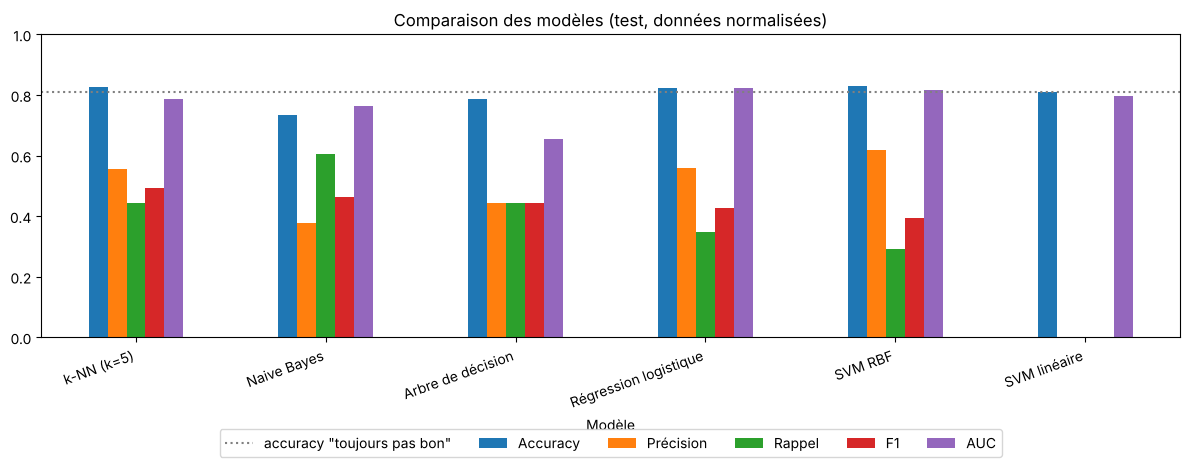

In [36]:
tab_norm[['Accuracy','Précision','Rappel','F1','AUC']].plot(kind='bar', figsize=(12,5), ylim=(0,1))
plt.title('Comparaison des modèles (test, données normalisées)'); plt.xticks(rotation=20, ha='right')
plt.axhline(1-Ytest.mean(), color='grey', ls=':', label='accuracy "toujours pas bon"')
plt.legend(loc='upper center', bbox_to_anchor=(0.5,-0.28), ncol=6)
plt.tight_layout(); plt.savefig('figures/09_comparaison_modeles.png', dpi=110, bbox_inches='tight'); plt.show()

## 3.2 Matrices de confusion

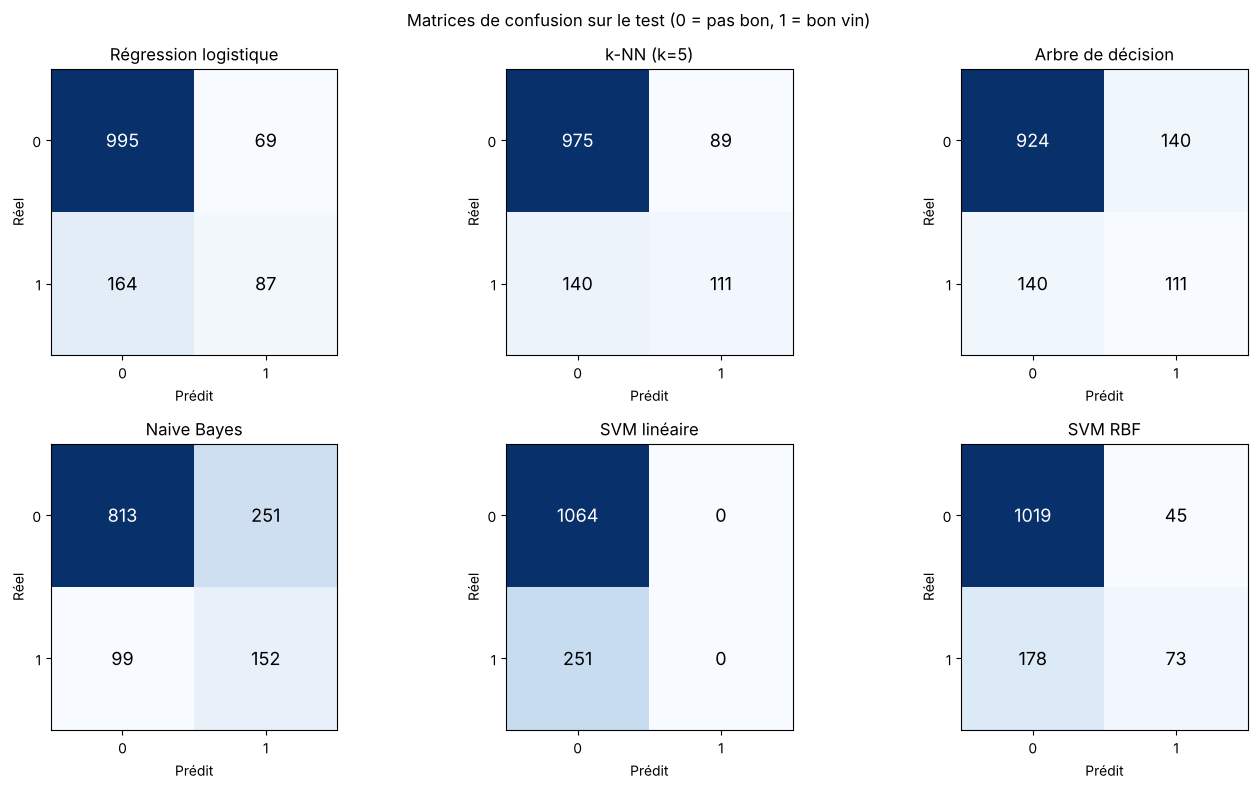

In [37]:
fig,axes=plt.subplots(2,3,figsize=(14,8))
for ax,(nom,modele) in zip(axes.ravel(),modeles.items()):
    m=clone(modele).fit(Xtrain_norm,Ytrain)
    cm=confusion_matrix(Ytest,m.predict(Xtest_norm))
    ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j,i,cm[i,j],ha='center',va='center',fontsize=13,color='white' if cm[i,j]>cm.max()/2 else 'black')
    ax.set_xticks([0,1]); ax.set_yticks([0,1]); ax.set_xlabel('Prédit'); ax.set_ylabel('Réel'); ax.set_title(nom)
plt.suptitle('Matrices de confusion sur le test (0 = pas bon, 1 = bon vin)')
plt.tight_layout(); plt.savefig('figures/10_matrices_confusion.png', dpi=110); plt.show()

## 3.3 Courbes ROC et AUC
Comme en séance 2 : la courbe ROC trace le taux de vrais positifs (rappel) en fonction du taux de faux positifs pour tous les seuils de décision ; l'AUC mesure la capacité à séparer les classes indépendamment du seuil (0,5 = hasard, 1 = parfait).

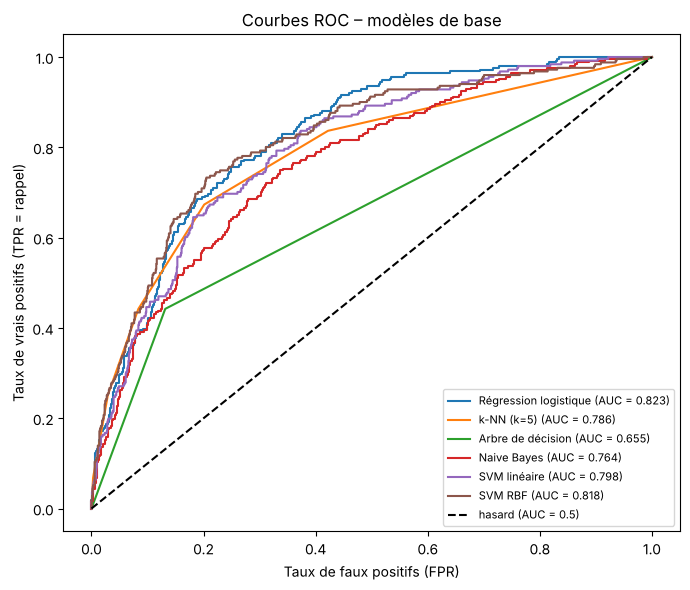

In [38]:
plt.figure(figsize=(7,6))
for nom,modele in modeles.items():
    m=clone(modele).fit(Xtrain_norm,Ytrain)
    score=m.predict_proba(Xtest_norm)[:,1]
    fpr,tpr,seuils=roc_curve(Ytest,score)
    plt.plot(fpr,tpr,label='{0} (AUC = {1:.3f})'.format(nom,roc_auc_score(Ytest,score)))
plt.plot([0,1],[0,1],'k--',label='hasard (AUC = 0.5)')
plt.xlabel('Taux de faux positifs (FPR)'); plt.ylabel('Taux de vrais positifs (TPR = rappel)')
plt.title('Courbes ROC – modèles de base'); plt.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.savefig('figures/11_roc_base.png', dpi=110); plt.show()

## 3.4 Compromis biais / variance
On compare l'erreur sur l'apprentissage et sur le test (tableau sous-apprentissage / sur-apprentissage de la séance 1), puis on estime la **stabilité** des modèles par validation croisée à 5 plis sur l'apprentissage (l'écart-type entre plis mesure la variance).

In [39]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=1)

biais_variance=[]
for nom,modele in modeles.items():
    cv=cross_val_score(clone(modele),Xtrain_norm,Ytrain,cv=skf,scoring='f1')
    biais_variance.append({'Modèle':nom,
                           'F1 train':tab_norm.loc[nom,'F1 train'],
                           'F1 test':tab_norm.loc[nom,'F1'],
                           'Écart train-test':tab_norm.loc[nom,'F1 train']-tab_norm.loc[nom,'F1'],
                           'F1 CV (moyenne)':cv.mean(),
                           'F1 CV (écart-type)':cv.std()})
tab_bv=pd.DataFrame(biais_variance).set_index('Modèle')
tab_bv

,F1 train,F1 test,Écart train-test,F1 CV (moyenne),F1 CV (écart-type)
Modèle,,,,,
Régression logistique,0.414,0.428,-0.013,0.411,0.036
k-NN (k=5),0.638,0.492,0.145,0.448,0.025
Arbre de décision,1.000,0.442,0.558,0.437,0.032
Naive Bayes,0.507,0.465,0.042,0.504,0.025
SVM linéaire,0.000,0.000,0.000,0.000,0.000
SVM RBF,0.463,0.396,0.067,0.404,0.009


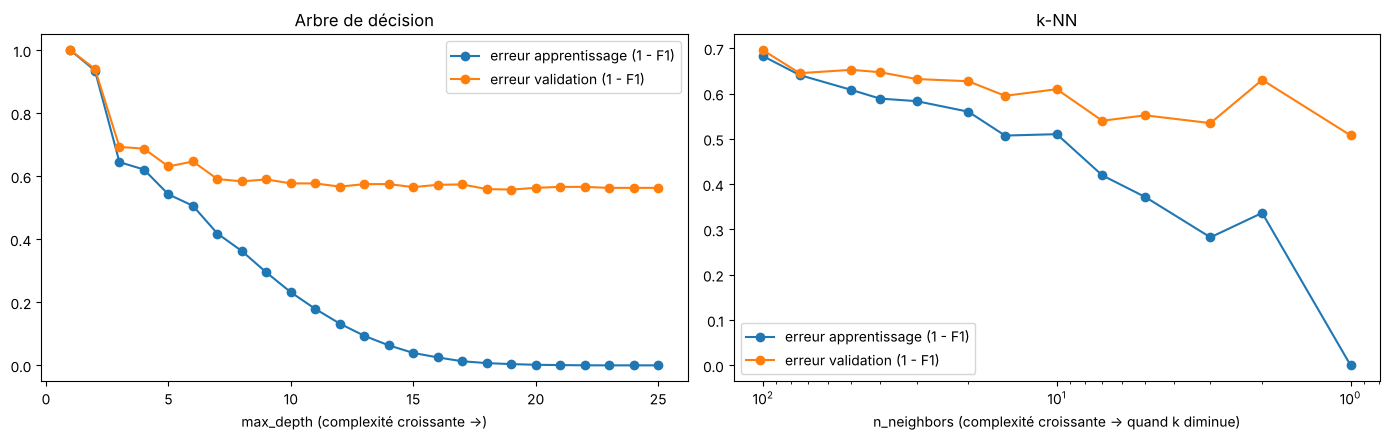

In [40]:
#Courbes de complexité : erreur d'apprentissage et de validation (CV 5 plis) selon la complexité du modèle
from sklearn.model_selection import validation_curve

fig,axes=plt.subplots(1,2,figsize=(14,4.5))
profondeurs=np.arange(1,26)
tr,va=validation_curve(DecisionTreeClassifier(random_state=0,criterion='entropy'),Xtrain_norm,Ytrain,
                       param_name='max_depth',param_range=profondeurs,cv=skf,scoring='f1')
axes[0].plot(profondeurs,1-tr.mean(axis=1),'o-',label='erreur apprentissage (1 - F1)')
axes[0].plot(profondeurs,1-va.mean(axis=1),'o-',label='erreur validation (1 - F1)')
axes[0].set_xlabel('max_depth (complexité croissante →)'); axes[0].set_title('Arbre de décision'); axes[0].legend()

voisins=np.array([1,2,3,5,7,10,15,20,30,40,50,75,100])
tr,va=validation_curve(KNeighborsClassifier(),Xtrain_norm,Ytrain,param_name='n_neighbors',
                       param_range=voisins,cv=skf,scoring='f1')
axes[1].plot(voisins,1-tr.mean(axis=1),'o-',label='erreur apprentissage (1 - F1)')
axes[1].plot(voisins,1-va.mean(axis=1),'o-',label='erreur validation (1 - F1)')
axes[1].set_xscale('log'); axes[1].invert_xaxis()
axes[1].set_xlabel('n_neighbors (complexité croissante → quand k diminue)'); axes[1].set_title('k-NN'); axes[1].legend()
plt.tight_layout(); plt.savefig('figures/12_biais_variance.png', dpi=110); plt.show()

**Lecture, à l'aide du tableau sous-apprentissage / sur-apprentissage de la séance 1 :**
- **Arbre de décision sans contrainte** : F1 = 1,000 en apprentissage contre 0,442 en test → **sur-apprentissage** (faible biais, forte variance). L'arbre pousse jusqu'à des feuilles pures et mémorise les exemples. La courbe de gauche le montre : l'erreur d'apprentissage tombe à 0 quand la profondeur augmente, tandis que l'erreur de validation stagne autour de 0,56 dès une dizaine de niveaux.
- **k-NN (k = 5)** : écart de 0,145 entre apprentissage et test → variance notable. Sur la courbe de droite, la complexité augmente quand k diminue. L'erreur de validation continue pourtant de baisser jusqu'à k = 1, car avec un grand k le vote est dominé par la classe majoritaire : sur ce jeu déséquilibré, les grands k « noient » les bons vins.
- **Régression logistique, Naive Bayes, SVM RBF** (paramètres par défaut) : écarts faibles (≤ 0,07) mais F1 modestes (0,40 à 0,50) → **biais** : le modèle ou son seuil de décision à 0,5 est défavorable à la classe minoritaire. Leurs AUC élevées (0,76 à 0,82) montrent qu'ils ordonnent bien les vins : le problème vient surtout du seuil.
- **SVM linéaire** : prédit toujours « pas bon » → sous-apprentissage complet.
- Les écarts-types en validation croisée sont faibles (≤ 0,036) : les résultats sont stables d'un pli à l'autre.

Avant optimisation, aucun modèle ne se détache : le k-NN a le meilleur F1 sur le test (0,492), Naive Bayes le meilleur F1 en validation croisée (0,504), la régression logistique la meilleure AUC (0,823). L'optimisation doit réduire la variance de l'arbre et du k-NN, et corriger le seuil des modèles biaisés (via `class_weight='balanced'`).

# 4. Optimisation des hyperparamètres (§2.4)

- **Grid Search** (`GridSearchCV`) : recherche exhaustive sur une grille – régression logistique, SVM RBF, Naive Bayes.
- **Random Search** (`RandomizedSearchCV`) : tirage aléatoire de combinaisons – arbre de décision et k-NN, dont les espaces de recherche sont plus grands.
- Chaque combinaison est évaluée par **validation croisée stratifiée à 5 plis** (*k-fold*) sur la base d'apprentissage uniquement. Le **test n'est utilisé qu'une seule fois**, à la fin, pour le modèle retenu (séance 1).
- Critère optimisé : **F1-score** de la classe « bon vin ».
- `class_weight='balanced'` fait partie des paramètres testés, pour compenser le déséquilibre des classes.

In [41]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint, loguniform

optimisations={}
def lancer(nom, recherche):
    debut=time.time()
    recherche.fit(Xtrain_norm,Ytrain)
    duree=time.time()-debut
    optimisations[nom]=recherche
    print('{0} : meilleur F1 CV = {1:.3f} en {2:.1f} s ({3} combinaisons)'.format(
          nom, recherche.best_score_, duree, len(recherche.cv_results_['params'])))
    print('   meilleurs paramètres :', recherche.best_params_)
    return duree

### 4.1 Grid Search

In [42]:
durees={}
durees['Régression logistique']=lancer('Régression logistique', GridSearchCV(
    LogisticRegression(max_iter=1000),
    {'C':[0.001,0.01,0.1,1,10,100],'class_weight':[None,'balanced']},
    cv=skf, scoring='f1', n_jobs=-1))

durees['Naive Bayes']=lancer('Naive Bayes', GridSearchCV(
    GaussianNB(),
    {'var_smoothing':np.logspace(-12,-1,12)},
    cv=skf, scoring='f1', n_jobs=-1))

durees['SVM RBF']=lancer('SVM RBF', GridSearchCV(
    SVC(kernel='rbf', random_state=0),
    {'C':[0.1,1,10,100],'gamma':['scale',0.01,0.1,1],'class_weight':[None,'balanced']},
    cv=skf, scoring='f1', n_jobs=-1))

Régression logistique : meilleur F1 CV = 0.549 en 1.8 s (12 combinaisons)
   meilleurs paramètres : {'C': 0.01, 'class_weight': 'balanced'}


Naive Bayes : meilleur F1 CV = 0.506 en 0.3 s (12 combinaisons)
   meilleurs paramètres : {'var_smoothing': np.float64(0.01)}


SVM RBF : meilleur F1 CV = 0.560 en 27.8 s (32 combinaisons)
   meilleurs paramètres : {'C': 100, 'class_weight': 'balanced', 'gamma': 0.01}


### 4.2 Random Search

In [43]:
durees['Arbre de décision']=lancer('Arbre de décision', RandomizedSearchCV(
    DecisionTreeClassifier(random_state=0),
    {'criterion':['entropy','gini'],'max_depth':list(range(2,31))+[None],
     'min_samples_leaf':randint(1,40),'class_weight':[None,'balanced']},
    n_iter=60, cv=skf, scoring='f1', random_state=0, n_jobs=-1))

durees['k-NN']=lancer('k-NN', RandomizedSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors':randint(1,60),'weights':['uniform','distance'],'p':[1,2]},
    n_iter=60, cv=skf, scoring='f1', random_state=0, n_jobs=-1))

Arbre de décision : meilleur F1 CV = 0.510 en 2.9 s (60 combinaisons)
   meilleurs paramètres : {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 24}


k-NN : meilleur F1 CV = 0.497 en 7.6 s (60 combinaisons)
   meilleurs paramètres : {'n_neighbors': 1, 'p': 1, 'weights': 'distance'}


### 4.3 Grid Search ou Random Search ? Comparaison sur le SVM RBF
On relance l'optimisation du SVM RBF avec un Random Search de 16 tirages (deux fois moins de combinaisons que la grille de 32) sur des intervalles continus de `C` et `gamma`.

In [44]:
debut=time.time()
rs_svm=RandomizedSearchCV(SVC(kernel='rbf', random_state=0),
    {'C':loguniform(0.1,1000),'gamma':loguniform(0.001,10),'class_weight':[None,'balanced']},
    n_iter=16, cv=skf, scoring='f1', random_state=0, n_jobs=-1).fit(Xtrain_norm,Ytrain)
duree_rs=time.time()-debut
gs_svm=optimisations['SVM RBF']
pd.DataFrame({'Grid Search':[len(gs_svm.cv_results_['params']), gs_svm.best_score_, durees['SVM RBF'], gs_svm.best_params_],
              'Random Search':[16, rs_svm.best_score_, duree_rs, {k:(round(v,4) if isinstance(v,float) else v) for k,v in rs_svm.best_params_.items()}]},
             index=['Combinaisons testées','Meilleur F1 (CV)','Temps (s)','Meilleurs paramètres'])

,Grid Search,Random Search
Combinaisons testées,32,16
Meilleur F1 (CV),0.56,0.545
Temps (s),27.846,16.968
Meilleurs paramètres,"{'C': 100, 'class_weight': 'balanced', 'gamma': 0.01}","{'C': 0.2231, 'class_weight': 'balanced', 'gamma': 0.0297}"


Avec deux fois moins de combinaisons, le Random Search obtient un F1 proche de celui de la grille (0,545 contre 0,560), en nettement moins de temps. Ici, la grille reste meilleure car l'espace de recherche est petit (deux paramètres continus et un paramètre binaire) et bien choisi. Le Random Search devient plus avantageux quand le nombre d'hyperparamètres augmente, ce qui justifie son usage pour l'arbre de décision (4 paramètres) et le k-NN.

### 4.4 Modèles optimisés : validation croisée et test

In [45]:
#Le SVM linéaire n'est pas réoptimisé : la famille linéaire est déjà couverte par la régression logistique
#(optimisée avec class_weight) et le SVM est couvert par la version à noyau RBF
resultats_opt=[]
for nom,recherche in optimisations.items():
    meilleur=clone(recherche.best_estimator_)
    if isinstance(meilleur,SVC): meilleur.set_params(probability=True)
    r=evaluer_modele(nom+' optimisé',meilleur,Xtrain_norm,Ytrain,Xtest_norm,Ytest,afficher=False)
    r['F1 CV']=recherche.best_score_
    resultats_opt.append(r)
tab_opt=tableau(resultats_opt)

avant_apres=pd.DataFrame({
    'F1 test avant':[tab_norm.loc[n,'F1'] for n in ['Régression logistique','k-NN (k=5)','Arbre de décision','Naive Bayes','SVM RBF']],
    'F1 test après':[tab_opt.loc[n+' optimisé','F1'] for n in ['Régression logistique','k-NN','Arbre de décision','Naive Bayes','SVM RBF']],
    'AUC avant':[tab_norm.loc[n,'AUC'] for n in ['Régression logistique','k-NN (k=5)','Arbre de décision','Naive Bayes','SVM RBF']],
    'AUC après':[tab_opt.loc[n+' optimisé','AUC'] for n in ['Régression logistique','k-NN','Arbre de décision','Naive Bayes','SVM RBF']]},
    index=['Régression logistique','k-NN','Arbre de décision','Naive Bayes','SVM RBF'])
print(avant_apres)
tab_opt[['F1 CV','Accuracy','Précision','Rappel','F1','AUC','Moy. acc+rappel (TP1)','F1 train']]

                       F1 test avant  F1 test après  AUC avant  AUC après
Régression logistique          0.428          0.518      0.823      0.823
k-NN                           0.492          0.488      0.786      0.685
Arbre de décision              0.442          0.506      0.655      0.808
Naive Bayes                    0.465          0.465      0.764      0.765
SVM RBF                        0.396          0.526      0.818      0.841


,F1 CV,Accuracy,Précision,Rappel,F1,AUC,Moy. acc+rappel (TP1),F1 train
Modèle,,,,,,,,
SVM RBF optimisé,0.560,0.721,0.389,0.813,0.526,0.841,0.767,0.583
Régression logistique optimisé,0.549,0.717,0.384,0.797,0.518,0.823,0.757,0.546
Arbre de décision optimisé,0.510,0.695,0.366,0.817,0.506,0.808,0.756,0.533
k-NN optimisé,0.497,0.802,0.482,0.494,0.488,0.685,0.648,1.000
Naive Bayes optimisé,0.506,0.734,0.377,0.606,0.465,0.765,0.670,0.505


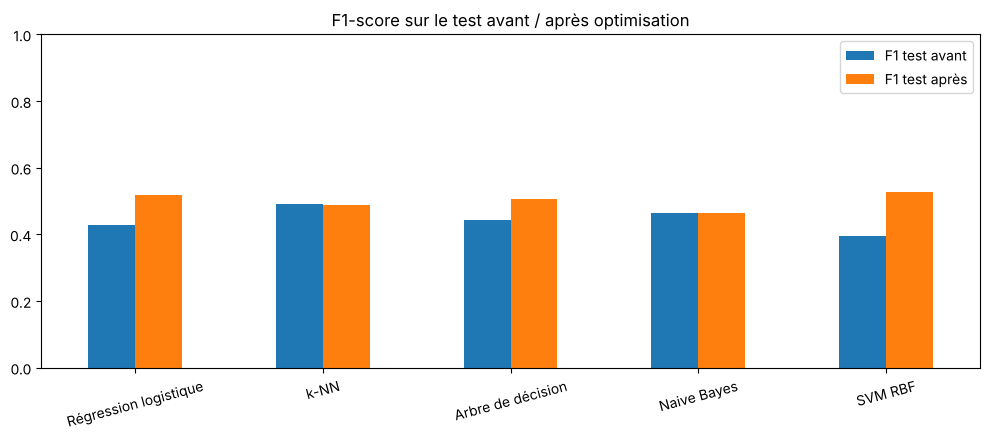

In [46]:
avant_apres[['F1 test avant','F1 test après']].plot(kind='bar', figsize=(10,4.5), ylim=(0,1))
plt.title('F1-score sur le test avant / après optimisation'); plt.xticks(rotation=15)
plt.tight_layout(); plt.savefig('figures/13_avant_apres_optimisation.png', dpi=110); plt.show()

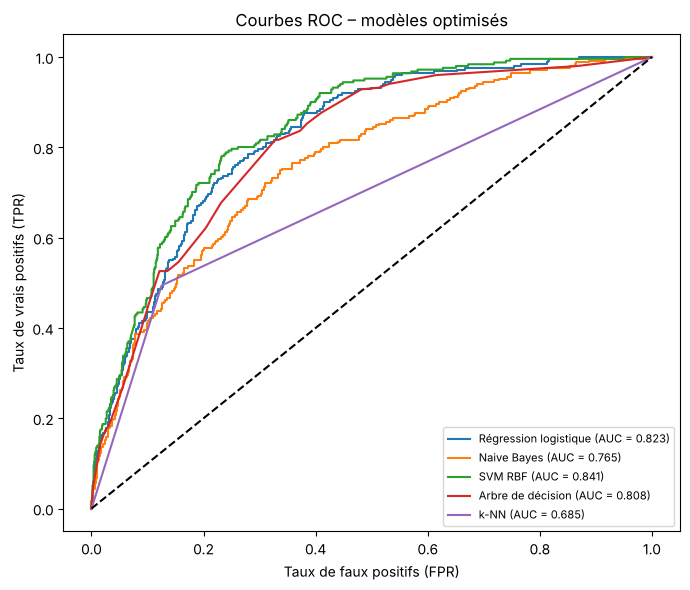

In [47]:
plt.figure(figsize=(7,6))
for nom,recherche in optimisations.items():
    meilleur=clone(recherche.best_estimator_)
    if isinstance(meilleur,SVC): meilleur.set_params(probability=True)
    meilleur.fit(Xtrain_norm,Ytrain)
    score=meilleur.predict_proba(Xtest_norm)[:,1]
    fpr,tpr,_=roc_curve(Ytest,score)
    plt.plot(fpr,tpr,label='{0} (AUC = {1:.3f})'.format(nom,roc_auc_score(Ytest,score)))
plt.plot([0,1],[0,1],'k--')
plt.xlabel('Taux de faux positifs (FPR)'); plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbes ROC – modèles optimisés'); plt.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.savefig('figures/14_roc_optimises.png', dpi=110); plt.show()

## 4.5 Choix du modèle final
Le modèle final est choisi sur le **F1-score en validation croisée** (et non sur le test, pour ne pas biaiser l'évaluation), en vérifiant ensuite sur le test l'AUC et l'écart apprentissage/test.

In [48]:
nom_final=max(optimisations,key=lambda n:optimisations[n].best_score_)
print('Modèle retenu :', nom_final)
print('Paramètres :', optimisations[nom_final].best_params_)

Modèle retenu : SVM RBF
Paramètres : {'C': 100, 'class_weight': 'balanced', 'gamma': 0.01}


In [49]:
from sklearn.pipeline import Pipeline
#Pipeline = normalisation + modèle : c'est l'objet que l'on sauvegarde pour l'application web
estimateur_final=clone(optimisations[nom_final].best_estimator_)
if isinstance(estimateur_final,SVC): estimateur_final.set_params(probability=True)
modele_final=Pipeline([('normalisation',StandardScaler()),('modele',estimateur_final)])
modele_final.fit(Xtrain,Ytrain)

Ypred_final=modele_final.predict(Xtest)
score_final=modele_final.predict_proba(Xtest)[:,1]
print ('************* Performance Evaluation of '+nom_final+' (modèle final) *************')
print(confusion_matrix(Ytest,Ypred_final))
print(classification_report(Ytest,Ypred_final))
print('AUC : {0:.3f}'.format(roc_auc_score(Ytest,score_final)))
print('F1 apprentissage : {0:.3f} | F1 test : {1:.3f}'.format(f1_score(Ytrain,modele_final.predict(Xtrain)),f1_score(Ytest,Ypred_final)))

************* Performance Evaluation of SVM RBF (modèle final) *************
[[744 320]
 [ 47 204]]
              precision    recall  f1-score   support

           0       0.94      0.70      0.80      1064
           1       0.39      0.81      0.53       251

    accuracy                           0.72      1315
   macro avg       0.66      0.76      0.66      1315
weighted avg       0.84      0.72      0.75      1315

AUC : 0.841


F1 apprentissage : 0.583 | F1 test : 0.526


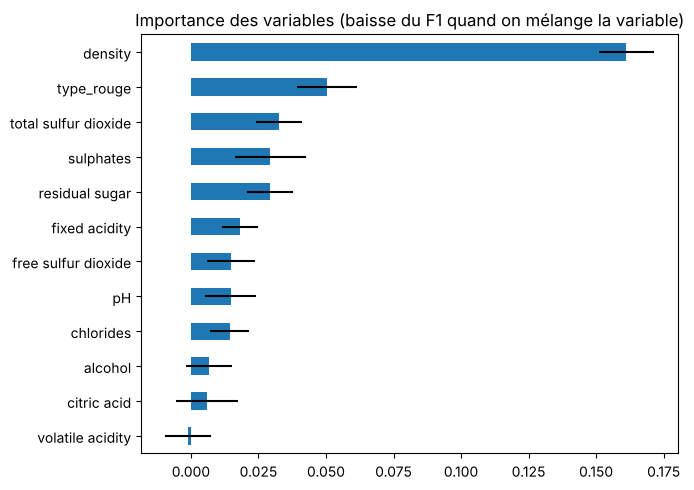

density                 0.161
type_rouge              0.050
total sulfur dioxide    0.033
sulphates               0.029
residual sugar          0.029
fixed acidity           0.018
free sulfur dioxide     0.015
pH                      0.015
chlorides               0.014
alcohol                 0.007
citric acid             0.006
volatile acidity       -0.001
dtype: float64


In [50]:
#Quelles variables comptent pour le modèle final ? (importance par permutation sur le test)
from sklearn.inspection import permutation_importance
imp=permutation_importance(modele_final,Xtest,Ytest,scoring='f1',n_repeats=10,random_state=0)
importance=pd.Series(imp.importances_mean,index=variables).sort_values()
importance.plot(kind='barh', figsize=(7,5), xerr=imp.importances_std[np.argsort(imp.importances_mean)])
plt.title('Importance des variables (baisse du F1 quand on mélange la variable)')
plt.tight_layout(); plt.savefig('figures/15_importance_variables.png', dpi=110); plt.show()
print(importance.sort_values(ascending=False).round(3))

In [51]:
#Sauvegarde du modèle final pour l'application web (bonus)
import joblib
os.makedirs('models', exist_ok=True)
joblib.dump({'modele':modele_final,'variables':variables,'nom':nom_final}, 'models/modele_final.joblib')
print('Modèle sauvegardé dans models/modele_final.joblib')

Modèle sauvegardé dans models/modele_final.joblib


**Lecture de l'importance des variables :** la **densité** est la variable dont le mélange dégrade le plus le modèle, suivie du type de vin et du SO₂ total. L'**alcool**, pourtant la variable la plus corrélée à la qualité, a une importance par permutation faible : il est fortement corrélé à la densité (r = −0,69). Quand on mélange l'alcool, le modèle retrouve l'essentiel de l'information dans la densité. L'importance par permutation mesure ce qu'une variable apporte *en plus des autres*, pas son lien avec la cible.

# 5. Conclusion

| Étape | Résultat principal |
|---|---|
| Prétraitement | 6 497 → 5 258 vins (1 177 doublons et 62 valeurs extrêmes retirés), aucune valeur manquante, 19,1 % de bons vins → jeu **déséquilibré** |
| Corrélations | Alcool (+0,42), densité (−0,30), chlorures (−0,19) et acidité volatile (−0,14) sont les plus liés à la qualité ; plusieurs variables sont redondantes |
| Normalisation | Indispensable pour k-NN et SVM, sans effet notable sur l'arbre et Naive Bayes |
| Sélection de variables | Noyau de 6 variables identifié, mais les 12 variables donnent de meilleurs F1 → toutes conservées |
| Modèles de base | F1 entre 0,40 et 0,49 ; arbre en sur-apprentissage, modèles linéaires biaisés vers la classe majoritaire |
| Optimisation | `class_weight='balanced'` retenu par tous les modèles qui l'acceptent : le rappel passe d'environ 0,3–0,4 à environ 0,8 |

**Modèle retenu : SVM à noyau RBF** (`C=100`, `gamma=0.01`, `class_weight='balanced'`) :
- meilleur F1 en validation croisée (0,560) et sur le test (0,526), meilleure AUC (0,841) et meilleure moyenne accuracy + rappel du TP1 (0,767) ;
- **meilleur compromis biais / variance** : F1 de 0,583 en apprentissage contre 0,526 en test (écart de 0,06), alors que le k-NN optimisé (k = 1) a un F1 de 1,0 en apprentissage ;
- il détecte **204 des 251 bons vins** du test (rappel 0,81), au prix de 320 faux positifs (précision 0,39). Ce compromis dépend du seuil de décision : selon l'usage, on peut le déplacer le long de la courbe ROC (par exemple vers plus de précision si l'on veut étiqueter une sélection « premium » sans erreur).

**Limites et perspectives :**
- La qualité est une **note sensorielle** donnée par des dégustateurs ; les 11 mesures physico-chimiques n'en expliquent qu'une partie, ce qui plafonne les performances (F1 autour de 0,5).
- Pistes d'amélioration : méthodes d'ensemble (forêts aléatoires, boosting), modèles séparés pour les rouges et les blancs, choix du seuil de décision par validation croisée, techniques de rééquilibrage des classes.